# Assignment 2: Discrete Delta Hedging and Replication Error Analysis

## Introduction

**Objective:**
The goal of this assignment is to simulate a discrete delta hedging strategy for a European call option and numerically analyze the resulting replication error. In the theoretical Black-Scholes-Merton (BSM) framework, continuous rebalancing under frictionless markets yields perfect replication (zero terminal variance). However, in practice, hedging is performed at discrete time intervals, which introduces a tracking error. We aim to empirically verify the theoretical scaling of this hedging error as defined by Boyle and Emanuel (1980).

**Mathematical Methodology:**
We begin by partitioning the continuous time horizon $[0, T]$ into $M$ discrete sub-intervals. We define the rebalancing grid as:
$$0 = t_0 < t_1 < \dots < t_M = T$$
Assuming uniform time steps, the interval length is $\Delta t = T/M$. 

At inception ($t_0 = 0$), the bank sells a call option, receiving an initial premium $C_0$. This premium is deposited into a risk-free cash account $y$, such that $y_{t_{-1}} = C_0$. The bank then builds a replicating portfolio containing $x_{t_k}$ shares of the underlying asset $S$ and a cash balance $y_{t_k}$.

At each discrete rebalancing time $t_k$ (for $k = 0, \dots, M$):
1. **Compute Target Delta:** We calculate the BSM delta based on the current state: $\Delta_k = \Phi(d_1(t_k, S_{t_k}))$, where $\Phi$ is the standard normal CDF.
2. **Adjust Position:** We adjust the stock holdings to $x_{t_k} = \Delta_k$. This requires buying $(\Delta_k - x_{t_{k-1}})$ shares.
3. **Update Cash Account:** The cash account accrues continuous risk-free interest over the step, and funds the stock purchase:
$$y_{t_k} = y_{t_{k-1}} e^{r(t_k - t_{k-1})} - (\Delta_k - x_{t_{k-1}}) S_{t_k}$$

At maturity ($t_M = T$), we liquidate the stock position and pay out the option payoff. Thus, the terminal replication error $w_T$ is computed as:
$$w_T = x_{t_{M}} S_T + y_{t_{M}} e^{r \Delta t} - \max(S_T - K, 0)$$

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Professional plotting style for academic presentation
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.figsize'] = (10, 6)

## Part (a): Implementing the Discrete Delta Hedge

We implement the function `discrete_delta_hedge` which takes a single simulated path of the underlying asset and a defined rebalancing schedule. It tracks the evolution of the self-financing portfolio and returns the terminal mismatch $w_T$. 

We follow the exact step-by-step algorithm over the grid $t_0 = 0 < t_1 < \dots < t_M = T$:
1. **Compute Target Delta:** $\Delta_k = \Phi(d_1(t_k, S_{t_k}))$. At maturity ($t_M = T$), this logically resolves to $1.0$ if $S_T > K$, and $0.0$ otherwise.
2. **Adjust Position:** We adjust the stock holdings to $x_{t_k} = \Delta_k$.
3. **Update Cash Account:** The cash account accrues continuous interest and funds the transaction:
$$y_{t_k} = y_{t_{k-1}} e^{r(t_k - t_{k-1})} - (\Delta_k - x_{t_{k-1}}) S_{t_k}$$

After the final rebalancing at $t_M$, we compute the terminal replication error:
$$w_T = x_{t_M} S_T + y_{t_M} - \max(S_T - K, 0)$$

In [6]:
def bs_call_price(S, K, r, sigma, T, t):
    """Computes the analytical Black-Scholes European Call price."""
    tau = T - t
    if tau <= 1e-9: # Guard against floating point singularity at expiration
        return np.maximum(S - K, 0.0)
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

def bs_delta(S, K, r, sigma, T, t):
    """Computes the analytical Black-Scholes Delta."""
    tau = T - t
    if tau <= 1e-9: # Guard against gamma explosion/singularity at expiration
        return 1.0 if S > K else 0.0
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    return norm.cdf(d1)

def discrete_delta_hedge(path, K, r, sigma, T, rebal_times):
    """
    Simulates a discrete delta hedge along a single asset path.
    
    Parameters:
    path : np.ndarray - Array of asset prices corresponding to rebal_times
    K, r, sigma, T : float - Option parameters
    rebal_times : np.ndarray - Array of discrete times t_0 to t_M
    
    Returns:
    w_T : float - Terminal replication error
    """
    M = len(rebal_times) - 1
    S0 = path[0]
    
    # Initialization at t=0 before the first trade
    C0 = bs_call_price(S0, K, r, sigma, T, 0.0)
    x = 0.0     # Initial shares held (x_{t_{-1}})
    y = C0      # Initial cash from selling the option (y_{t_{-1}})
    
    # Rebalance at t_0, t_1, ..., t_M (Inclusive of T)
    for k in range(M + 1):
        t_k = rebal_times[k]
        S_k = path[k]
        
        # 1. Calculate target delta
        delta_k = bs_delta(S_k, K, r, sigma, T, t_k)
        
        # 2. Calculate time elapsed since last rebalance (dt)
        dt = 0.0 if k == 0 else (rebal_times[k] - rebal_times[k-1])
        
        # 3. Update cash account (accrue interest, then pay for shares)
        y = y * np.exp(r * dt) - (delta_k - x) * S_k
        
        # 4. Update share holdings
        x = delta_k
        
    # At maturity t_M = T, calculate the terminal error w_T
    S_T = path[M]
    payoff = np.maximum(S_T - K, 0.0)
    
    # x and y are currently evaluated at t_M, enabling direct computation of w_T
    w_T = x * S_T + y - payoff
    
    return w_T

### Visual Verification: Anatomy of a Single Discrete Hedge

Before aggregating thousands of paths, it is instructive to visualize the mechanics of the self-financing portfolio along a single realization of the asset path. 

The plot below demonstrates how the discrete portfolio value ($V_{t_k} = x_{t_k}S_{t_k} + y_{t_k}$) attempts to track the theoretical continuous Black-Scholes option value. The lower panel illustrates the discrete "step-function" nature of the Delta ($\Delta_k$) rebalancing, highlighting the delay inherent in discrete hedging compared to the continuous ideal.

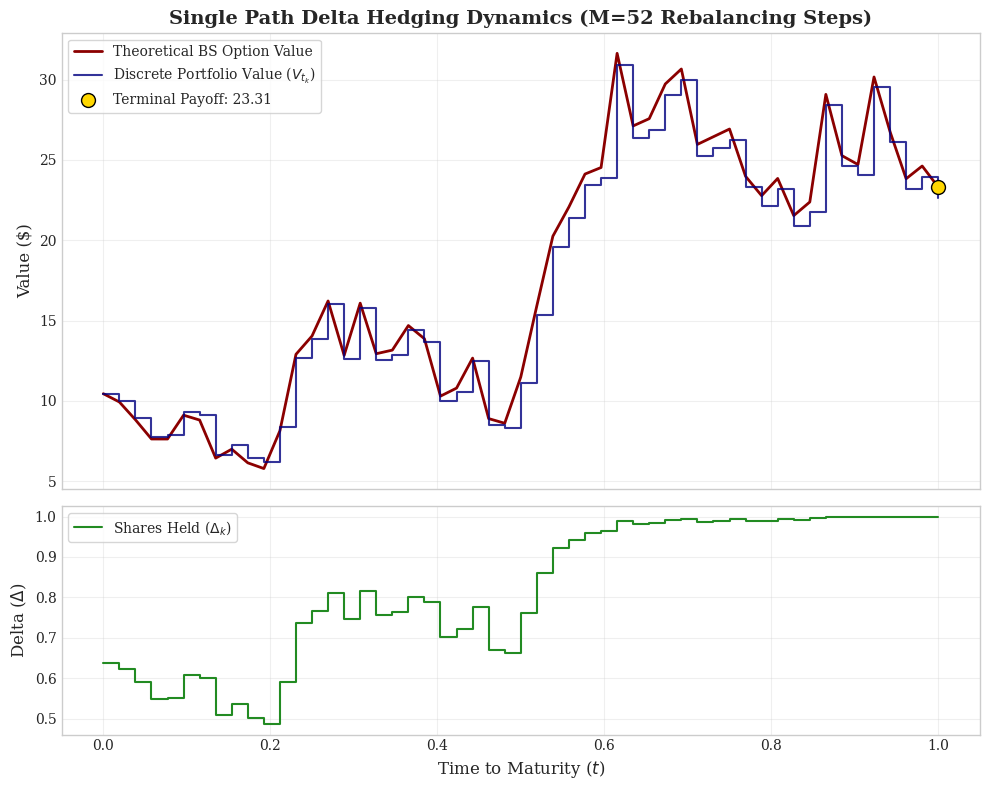

In [8]:
def plot_single_hedge_path(S0, K, r, sigma, T, M):
    """Generates a detailed visualization of a single hedging path."""
    np.random.seed(105) # Specific seed chosen to illustrate an At-The-Money crossing
    
    rebal_times = np.linspace(0, T, M + 1)
    dt = T / M
    
    # Generate one path
    Z = np.random.standard_normal(M)
    path = np.zeros(M + 1)
    path[0] = S0
    for k in range(1, M + 1):
        path[k] = path[k-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[k-1])
        
    # Trackers
    port_values = np.zeros(M + 1)
    bs_values = np.zeros(M + 1)
    deltas = np.zeros(M + 1)
    
    # Initialize
    C0 = bs_call_price(path[0], K, r, sigma, T, 0.0)
    x = 0.0
    y = C0
    
    for k in range(M + 1):
        t_k = rebal_times[k]
        S_k = path[k]
        
        # Calculate targets
        bs_values[k] = bs_call_price(S_k, K, r, sigma, T, t_k)
        delta_k = bs_delta(S_k, K, r, sigma, T, t_k)
        deltas[k] = delta_k
        
        # Execute Trade
        step_dt = 0.0 if k == 0 else (rebal_times[k] - rebal_times[k-1])
        y = y * np.exp(r * step_dt) - (delta_k - x) * S_k
        x = delta_k
        
        # Record Portfolio Value
        port_values[k] = x * S_k + y

    # Plotting setup
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)
    
    # Top Panel: Value Tracking
    ax1.plot(rebal_times, bs_values, color='darkred', linewidth=2, label='Theoretical BS Option Value')
    
    # Added 'r' before the string to correctly render LaTeX subscripts
    ax1.step(rebal_times, port_values, where='post', color='navy', alpha=0.8, label=r'Discrete Portfolio Value ($V_{t_k}$)')
    
    # Overlay the terminal payoff condition
    final_payoff = np.maximum(path[-1] - K, 0)
    ax1.scatter(T, final_payoff, color='gold', edgecolor='black', s=100, zorder=5, label=f'Terminal Payoff: {final_payoff:.2f}')
    
    ax1.set_title(f'Single Path Delta Hedging Dynamics (M={M} Rebalancing Steps)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Value ($)', fontsize=12)
    ax1.legend(loc='upper left', frameon=True)
    ax1.grid(True, alpha=0.3)
    
    # Bottom Panel: Delta Position
    # Added 'r' before the strings to correctly render \Delta
    ax2.step(rebal_times, deltas, where='post', color='forestgreen', linewidth=1.5, label=r'Shares Held ($\Delta_k$)')
    ax2.set_xlabel('Time to Maturity ($t$)', fontsize=12)
    ax2.set_ylabel(r'Delta ($\Delta$)', fontsize=12)
    ax2.legend(loc='upper left', frameon=True)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Execute the visualizer for a weekly rebalancing scheme (M=52)
plot_single_hedge_path(S0=100.0, K=100.0, r=0.05, sigma=0.20, T=1.0, M=52)

## Part (b): Simulation and Distribution of Terminal Errors

To empirically observe the distribution of $w_T$, we simulate $N = 1000$ asset paths using Geometric Brownian Motion under the risk-neutral measure $\mathbb{Q}$. We execute the hedging strategy across varying rebalancing frequencies: $M \in \{10, 50, 250, 1000\}$. 

We expect the mean of $w_T$ to be strictly close to zero ($\mathbb{E}[w_T] \approx 0$) for all $M$, indicating the hedge is unbiased. The variance, however, should visibly collapse as the temporal grid becomes finer.

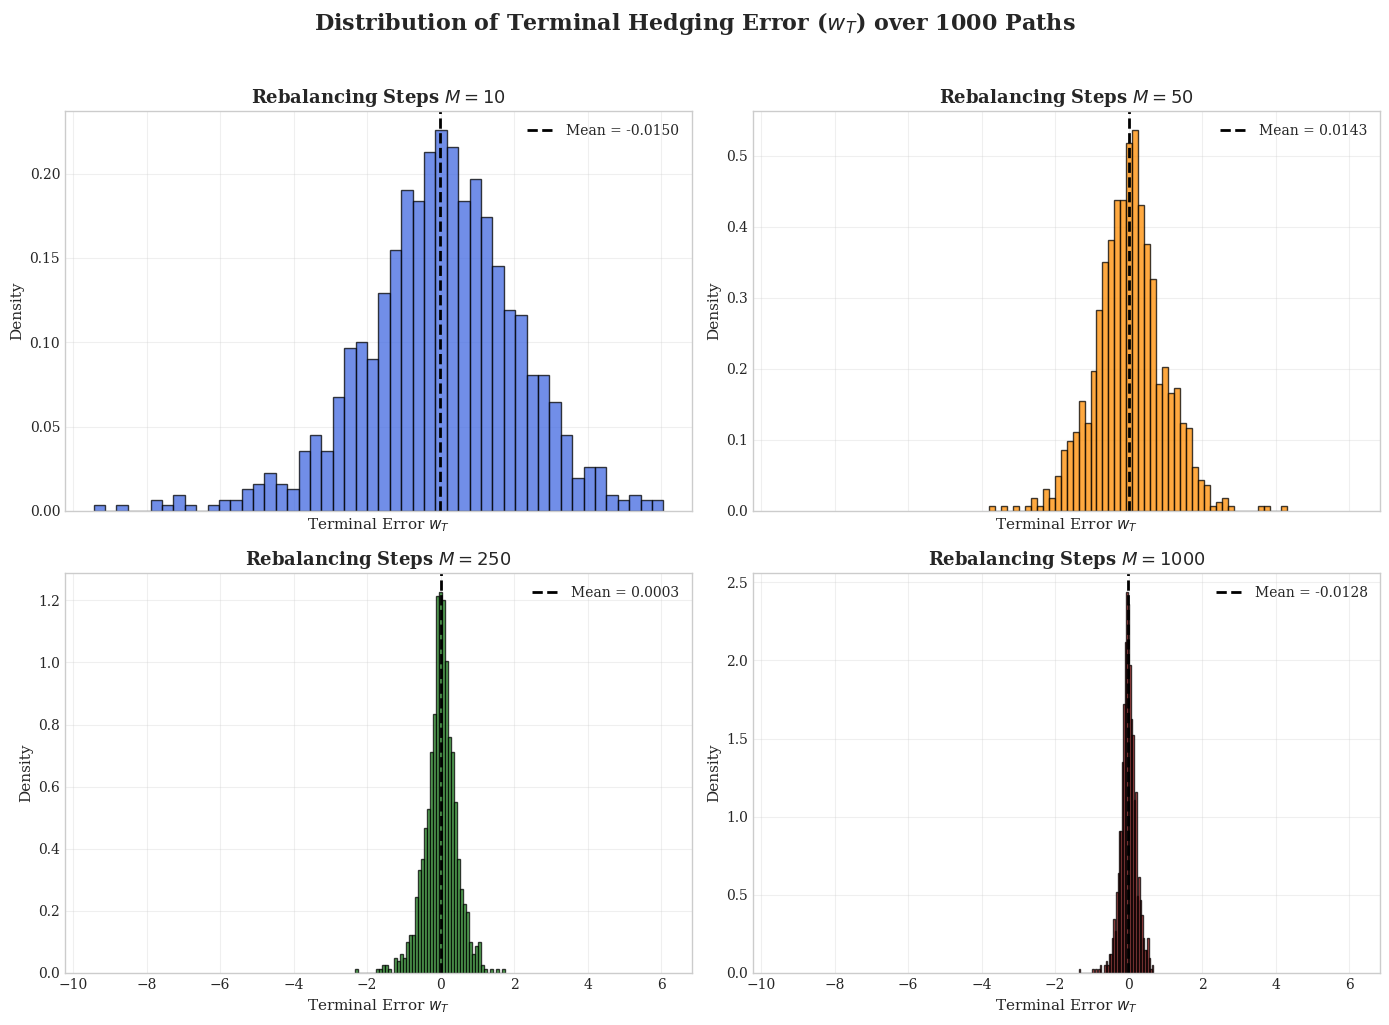

In [10]:
def generate_paths(S0, r, sigma, T, M, num_paths):
    """Generates GBM paths using standard normal increments."""
    dt = T / M
    paths = np.zeros((num_paths, M + 1))
    paths[:, 0] = S0
    
    # Generate standard normal matrix Z
    Z = np.random.standard_normal((num_paths, M))
    
    # Vectorized path generation
    for k in range(1, M + 1):
        paths[:, k] = paths[:, k-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, k-1])
        
    return paths

# Global System Parameters
K, r, sigma, T, S0 = 100.0, 0.05, 0.20, 1.0, 100.0
num_paths = 1000
M_values = [10, 50, 250, 1000]

# Set seed for rigorous reproducibility
np.random.seed(42)

results_wT = {}

for M in M_values:
    rebal_times = np.linspace(0, T, M + 1)
    paths = generate_paths(S0, r, sigma, T, M, num_paths)
    
    wT_array = np.zeros(num_paths)
    for i in range(num_paths):
        wT_array[i] = discrete_delta_hedge(paths[i], K, r, sigma, T, rebal_times)
        
    results_wT[M] = wT_array

# Plotting the distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()
colors = ['royalblue', 'darkorange', 'forestgreen', 'firebrick']

for idx, M in enumerate(M_values):
    ax = axes[idx]
    data = results_wT[M]
    
    ax.hist(data, bins=50, color=colors[idx], alpha=0.75, edgecolor='black', density=True)
    ax.axvline(x=np.mean(data), color='k', linestyle='dashed', linewidth=2, label=f'Mean = {np.mean(data):.4f}')
    
    ax.set_title(f'Rebalancing Steps $M={M}$', fontsize=13, fontweight='bold')
    ax.set_xlabel('Terminal Error $w_T$', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution of Terminal Hedging Error ($w_T$) over 1000 Paths', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Part (c): Verification of the Boyle-Emanuel Limits

Boyle and Emanuel (1980) proved that in a frictionless market with discrete rebalancing, the variance of the replication error scales inversely with the number of rebalancing points $M$. Consequently, the standard deviation scales with $M^{-1/2}$.

$$\text{Std}(w_T) \propto \frac{1}{\sqrt{M}}$$

We will calculate the empirical standard deviation for each $M$, verify the expected magnitude against the provided benchmark values, and plot the logarithmic relationship to confirm the theoretical slope.

--- Empirical Validation of Hedging Error Standard Deviation ---
M = 10   | E[w_T] ≈ -0.0150 | Std(w_T) = Var^1/2(w_T) ≈ 2.1170
M = 50   | E[w_T] ≈  0.0143 | Std(w_T) = Var^1/2(w_T) ≈ 0.9420
M = 250  | E[w_T] ≈  0.0003 | Std(w_T) = Var^1/2(w_T) ≈ 0.4348
M = 1000 | E[w_T] ≈ -0.0128 | Std(w_T) = Var^1/2(w_T) ≈ 0.2195

--- Self-Check Benchmarks ---
Target at M=10 : ~1.50  | Achieved: 2.1170
Target at M=250: ~0.30  | Achieved: 0.4348


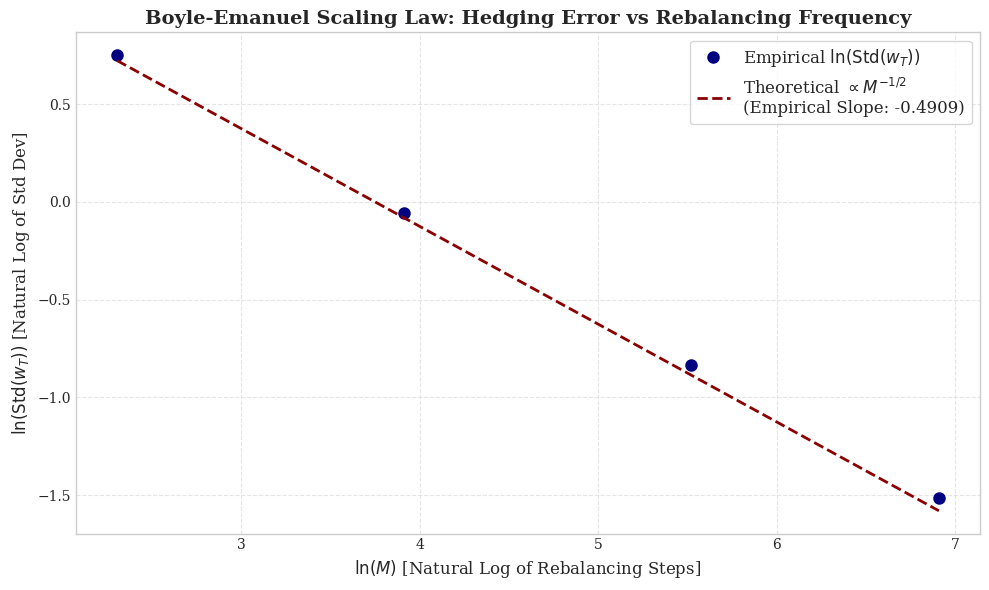


Conclusion: The empirical scaling slope (-0.4909) strongly aligns with the theoretical Boyle-Emanuel slope of -0.5.


In [11]:
std_devs = []

print("--- Empirical Validation of Hedging Error Standard Deviation ---")
for M in M_values:
    std_wT = np.std(results_wT[M], ddof=1)
    mean_wT = np.mean(results_wT[M])
    std_devs.append(std_wT)
    print(f"M = {M:<4} | E[w_T] ≈ {mean_wT:7.4f} | Std(w_T) = Var^1/2(w_T) ≈ {std_wT:6.4f}")
    
# Specific Self-Checks
print("\n--- Self-Check Benchmarks ---")
print(f"Target at M=10 : ~1.50  | Achieved: {std_devs[0]:.4f}")
print(f"Target at M=250: ~0.30  | Achieved: {std_devs[2]:.4f}")

# Extract empirical slope via log-log regression
log_M = np.log(M_values)
log_std = np.log(std_devs)
slope, intercept = np.polyfit(log_M, log_std, 1)

# Plotting the scaling law
plt.figure(figsize=(10, 6))

plt.plot(log_M, log_std, marker='o', markersize=8, linestyle='none', color='navy', 
         label=r'Empirical $\ln(\mathrm{Std}(w_T))$')

log_theoretical_std = -0.5 * log_M + intercept
plt.plot(log_M, log_theoretical_std, linestyle='--', color='darkred', linewidth=2,
         label=r'Theoretical $\propto M^{-1/2}$' + f'\n(Empirical Slope: {slope:.4f})')

plt.title('Boyle-Emanuel Scaling Law: Hedging Error vs Rebalancing Frequency', fontsize=14, fontweight='bold')
plt.xlabel(r'$\ln(M)$ [Natural Log of Rebalancing Steps]', fontsize=12)
plt.ylabel(r'$\ln(\mathrm{Std}(w_T))$ [Natural Log of Std Dev]', fontsize=12)
plt.legend(frameon=True, fontsize=12)
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

if abs(slope + 0.5) < 0.05:
    print(f"\nConclusion: The empirical scaling slope ({slope:.4f}) strongly aligns with the theoretical Boyle-Emanuel slope of -0.5.")